In [1]:
import logging
from trails import Trails, lca, get_lcia_method_names, plot_temporal_scores
from datapackage import Package
from trails.logging import configure_trails_logging, trails_log_context

configure_trails_logging(file_level=logging.DEBUG)

dp = Package("datapackage.json")
#dp = Package("/Users/romain/GitHub/premise/dev/trails_2025-12-30.zip")
trails = Trails(dp, interpolate_annual=True, debug=True)

#methods = ["IPCC 2021 - climate change: fossil - global warming potential (GWP100)",]
methods = ["IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)",]

Loaded interpolated matrices from cache: /Users/romain/Library/Application Support/trails/cache/interp_592d90d85ab3ba07ecc1471b0d8adddb69a0cb5531d0d21f24324d06f991dc27


In [2]:
from trails.plotting import plot_temporal_graph

trails.temporal_routing(
  start_year=2050,
  start_act_idx=13,
  amount=1.0,
  max_depth=3,
  show_progress=True,
  attribute_to_roots=True,
)

trails.lca(
    methods=methods,
    show_progress=True,
    compute_score=True,
    store_inventory=True,
)

Temporal routing: 1259node [00:01, 1042.51node/s]
Temporal LCA: solve years: 100%|█████████████| 41/41 [00:00<00:00, 440.13year/s]


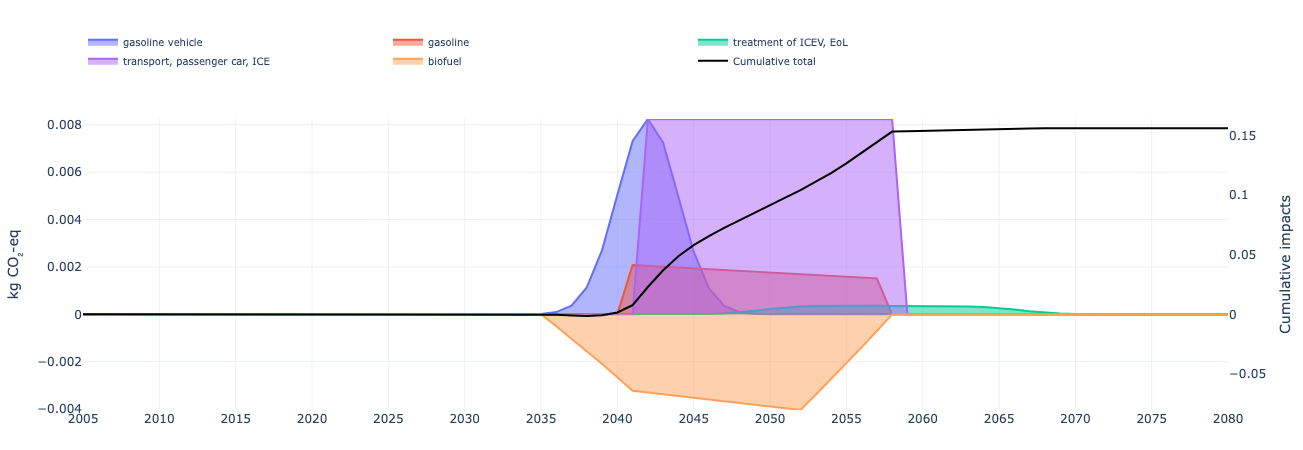

In [3]:
fig = plot_temporal_scores(
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

In [4]:
from trails.fair_rf import run_fair_delta_rf

rf = run_fair_delta_rf(
    trails,
    scenario="high-extension",
    scale_target_fraction=0.1,
)

/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

FaIR per-species: 100%|████████████| 2/2 [00:01<00:00,  1.80specie/s, CO2 AFOLU]


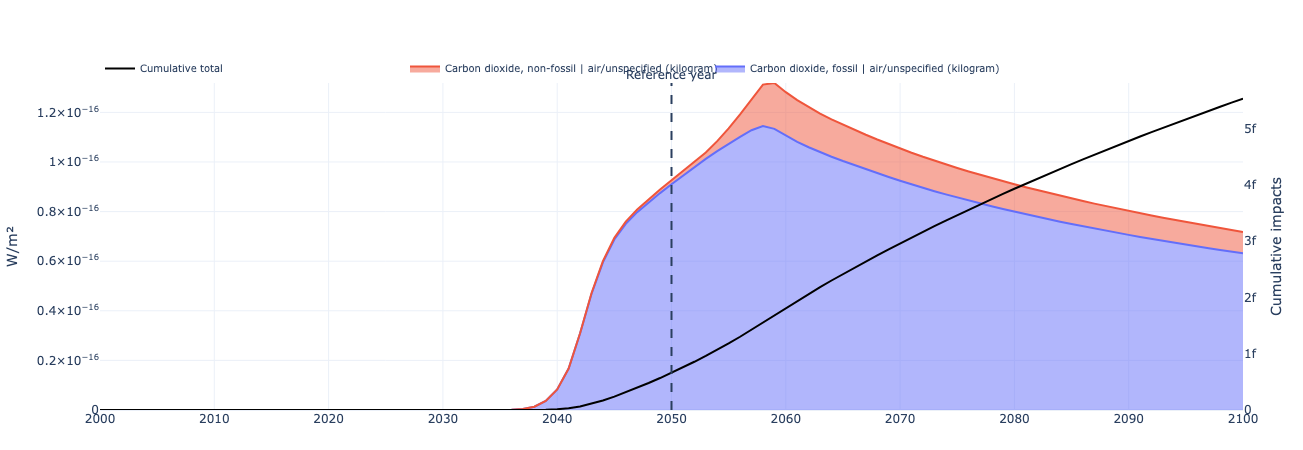

In [5]:
from trails.plotting import plot_rf

fig = plot_rf(
    trails=trails,
    reference_year=2050,
    by="flow",
    year_range=(2000, 2100),
    year_tick=10,
    #show_cumulative_quantile_band=True
    #y_max=0.2e-16
)
fig.show()

In [6]:
print("rf dims:", trails.instant_radiative_forcing.dims)
print("rf shape:", trails.instant_radiative_forcing.shape)
print("rf nnz:", int(getattr(trails.instant_radiative_forcing.data, "nnz", 0)))

print("temp dims:", trails.delta_temperature.dims)
print("temp shape:", trails.delta_temperature.shape)
print("temp nnz:", int(getattr(trails.delta_temperature.data, "nnz", 0)))

rf dims: ('year', 'flow', 'root activity')
rf shape: (751, 2, 17)
rf nnz: 3223
temp dims: ('year', 'flow', 'root activity')
temp shape: (751, 2, 17)
temp nnz: 3223


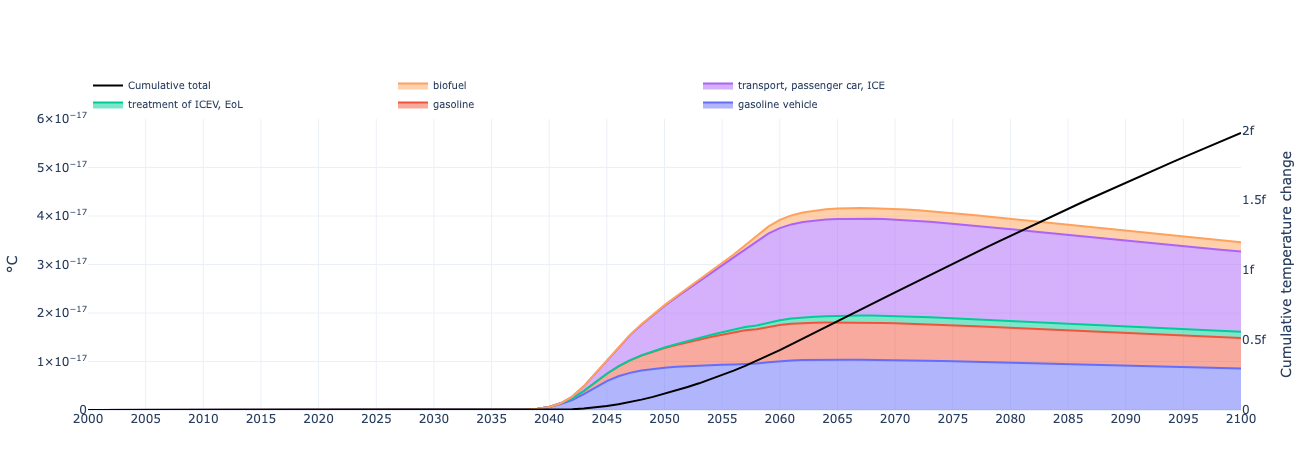

In [9]:
from trails import plot_temp

plot_temp(
    trails,
    by="root activity",
    title="Temperature change by root activity",
    method_label="°C",
    year_range=(2000, 2100),
    y_max=0.6e-16,
    #show_cumulative_quantile_band=True
)


In [ ]:
rf = trails.instant_radiative_forcing
p5 = rf.sel(quantile=5).sum(dim=["flow", "root activity"])
p95 = rf.sel(quantile=95).sum(dim=["flow", "root activity"])
print("max band width:", float((p95 - p5).max().values))

